# ⭐ Day 41: CIFAR-10 Basic EDA
## 🖼️ Computer Vision Dataset Guide for Color Images
### Day 41 of 369-day Python & AI Learning Path

---


## 🌈 Welcome to Day 41!

Congratulations on reaching Day 41 of your Python & AI journey! Today marks a significant milestone as we transition from simple grayscale datasets to the vibrant world of **color image analysis**. While MNIST taught us the fundamentals with handwritten digits, CIFAR-10 presents a much more realistic and challenging computer vision scenario.

The CIFAR-10 dataset is one of the most widely used benchmarks in computer vision research. It consists of 60,000 tiny 32×32 color images spread across 10 distinct object classes. What makes this dataset particularly valuable is its complexity—unlike the uniform backgrounds of MNIST, CIFAR-10 images feature real-world objects photographed from various angles, under different lighting conditions, and against diverse backgrounds. This realism makes it an excellent training ground for developing robust deep learning models.

In this notebook, we'll conduct a comprehensive Exploratory Data Analysis (EDA) that goes beyond simple visualization. We'll dissect the RGB channels, analyze color distributions across classes, compute statistical properties, and visualize what makes each class visually distinct. These insights will prove invaluable when you design convolutional neural networks and data augmentation strategies in future lessons.

By the end of this session, you'll understand how to:
- 🎯 Navigate and inspect color image datasets
- 📊 Analyze RGB channel distributions and their class-specific patterns
- 🔍 Identify visual signatures that distinguish different object categories
- 💡 Extract actionable insights for model architecture decisions
- ✅ Prepare color image data for deep learning pipelines

Let's dive into the colorful world of CIFAR-10! 🚀


## 📋 Table of Contents

1. [Introduction to CIFAR-10 Dataset](#1-introduction-to-cifar-10-dataset)
2. [Loading the Dataset](#2-loading-the-dataset)
3. [Basic Dataset Inspection](#3-basic-dataset-inspection)
4. [Visualizing Sample Images](#4-visualizing-sample-images)
5. [Class Distribution Analysis](#5-class-distribution-analysis)
6. [RGB Channel Analysis](#6-rgb-channel-analysis)
7. [Pixel Value Distribution](#7-pixel-value-distribution-across-the-dataset)
8. [Image Statistics](#8-image-statistics)
9. [Visualizing Average Image per Class](#9-visualizing-average-image-per-class)
10. [Key Insights for Computer Vision](#10-key-insights-for-computer-vision--deep-learning)
11. [Data Preparation Preview](#11-data-preparation-preview)
12. [🛠️ Hands-On Exercises](#-hands-on-exercises)
13. [Solutions & Key Insights](#-solutions--key-insights-review-after-attempting)


## 1. Introduction to CIFAR-10 Dataset

**CIFAR-10** (Canadian Institute for Advanced Research) is a foundational dataset in computer vision:

- **Total Images**: 60,000 color images
- **Image Size**: 32 × 32 pixels (small but challenging!)
- **Channels**: 3 (RGB - Red, Green, Blue)
- **Classes**: 10 distinct object categories
- **Split**: 50,000 training + 10,000 test images
- **Balance**: Perfectly balanced (6,000 images per class)

**The 10 Classes:**
0. ✈️ Airplane
1. 🚗 Automobile
2. 🐦 Bird
3. 🐱 Cat
4. 🦌 Deer
5. 🐕 Dog
6. 🐸 Frog
7. 🐴 Horse
8. 🚢 Ship
9. 🚛 Truck

Why CIFAR-10 matters: The small image size forces models to learn efficient, robust features rather than relying on fine details. Success on CIFAR-10 often indicates a model's ability to generalize well to larger, more complex datasets like ImageNet.


In [1]:
# 📦 Import essential libraries for CIFAR-10 EDA
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import cifar10
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# 🎨 Set up beautiful visualization defaults
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Define class names with emojis for better visualization
CLASS_NAMES = [
    '✈️ Airplane', '🚗 Automobile', '🐦 Bird', '🐱 Cat', 
    '🦌 Deer', '🐕 Dog', '🐸 Frog', '🐴 Horse', 
    '🚢 Ship', '🚛 Truck'
]

print("✅ Libraries imported successfully!")
print("🎯 Ready to explore CIFAR-10 dataset")


✅ Libraries imported successfully!
🎯 Ready to explore CIFAR-10 dataset


## 2. Loading the Dataset

We'll use Keras's built-in dataset loader, which downloads CIFAR-10 automatically on first run. The dataset comes pre-split into training and test sets.


In [2]:
# 📥 Load CIFAR-10 dataset using Keras
print("⏳ Loading CIFAR-10 dataset...")
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("✅ Dataset loaded successfully!")
print(f"\n📊 Dataset Structure:")
print(f"   Training images shape: {x_train.shape}")
print(f"   Training labels shape: {y_train.shape}")
print(f"   Test images shape:     {x_test.shape}")
print(f"   Test labels shape:     {y_test.shape}")
print(f"\n💾 Total memory usage: ~{(x_train.nbytes + x_test.nbytes) / 1024 / 1024:.1f} MB")


⏳ Loading CIFAR-10 dataset...
✅ Dataset loaded successfully!

📊 Dataset Structure:
   Training images shape: (50000, 32, 32, 3)
   Training labels shape: (50000, 1)
   Test images shape:     (10000, 32, 32, 3)
   Test labels shape:     (10000, 1)

💾 Total memory usage: ~175.8 MB


## 3. Basic Dataset Inspection

Let's examine the fundamental properties of our color image dataset.


In [3]:
# 🔍 Comprehensive dataset inspection
print("=" * 60)
print("🔬 CIFAR-10 DATASET INSPECTION REPORT")
print("=" * 60)

# Image dimensions
print(f"\n📐 Image Dimensions:")
print(f"   • Height: {x_train.shape[1]} pixels")
print(f"   • Width:  {x_train.shape[2]} pixels")
print(f"   • Channels: {x_train.shape[3]} (RGB)")

# Data types and ranges
print(f"\n💾 Data Properties:")
print(f"   • Data type: {x_train.dtype}")
print(f"   • Pixel value range: [{x_train.min()}, {x_train.max()}]")
print(f"   • Unique pixel values: {len(np.unique(x_train))}")

# Label structure
print(f"\n🏷️ Label Structure:")
print(f"   • Label shape: {y_train.shape}")
print(f"   • Label data type: {y_train.dtype}")
print(f"   • Unique classes: {np.unique(y_train).tolist()}")

print(f"\n📈 Sample Counts:")
print(f"   • Training samples: {len(x_train):,}")
print(f"   • Test samples: {len(x_test):,}")
print(f"   • Total samples: {len(x_train) + len(x_test):,}")

# Class distribution in training set
train_counts = Counter(y_train.flatten())
print(f"\n📊 Training Set Class Distribution:")
for class_id, count in sorted(train_counts.items()):
    print(f"   • {CLASS_NAMES[class_id]}: {count:,} images")

print("\n" + "=" * 60)


🔬 CIFAR-10 DATASET INSPECTION REPORT

📐 Image Dimensions:
   • Height: 32 pixels
   • Width:  32 pixels
   • Channels: 3 (RGB)

💾 Data Properties:
   • Data type: uint8
   • Pixel value range: [0, 255]
   • Unique pixel values: 256

🏷️ Label Structure:
   • Label shape: (50000, 1)
   • Label data type: uint8
   • Unique classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

📈 Sample Counts:
   • Training samples: 50,000
   • Test samples: 10,000
   • Total samples: 60,000

📊 Training Set Class Distribution:
   • ✈️ Airplane: 5,000 images
   • 🚗 Automobile: 5,000 images
   • 🐦 Bird: 5,000 images
   • 🐱 Cat: 5,000 images
   • 🦌 Deer: 5,000 images
   • 🐕 Dog: 5,000 images
   • 🐸 Frog: 5,000 images
   • 🐴 Horse: 5,000 images
   • 🚢 Ship: 5,000 images
   • 🚛 Truck: 5,000 images



## 4. Visualizing Sample Images

Let's create a beautiful grid showing random samples from each of the 10 classes. This gives us an immediate sense of the visual diversity and challenges in the dataset.


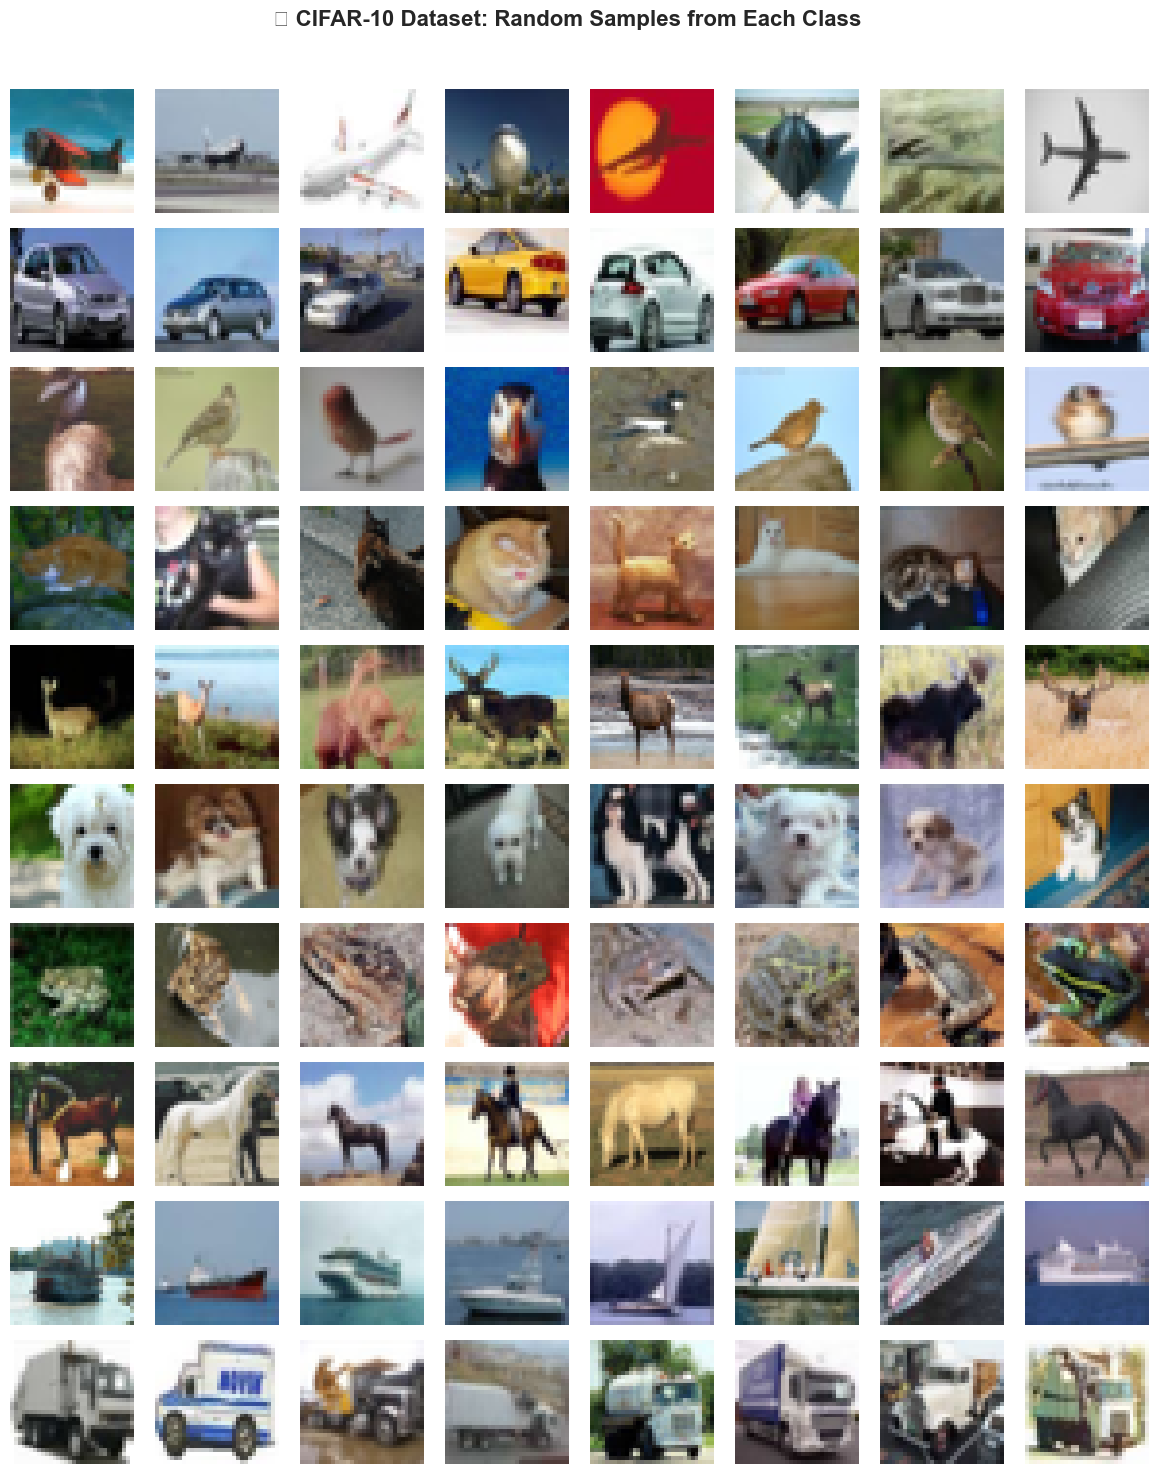

In [4]:
# 🖼️ Create a comprehensive visualization grid
def plot_class_samples(images, labels, class_names, samples_per_class=8):
    """Display random samples from each class in a grid."""
    num_classes = len(class_names)
    fig, axes = plt.subplots(num_classes, samples_per_class, 
                            figsize=(samples_per_class * 1.5, num_classes * 1.5))
    
    fig.suptitle('🌈 CIFAR-10 Dataset: Random Samples from Each Class', 
                 fontsize=16, fontweight='bold', y=0.98)
    
    for class_id in range(num_classes):
        # Find indices for this class
        indices = np.where(labels.flatten() == class_id)[0]
        # Randomly sample
        selected_indices = np.random.choice(indices, samples_per_class, replace=False)
        
        for i, idx in enumerate(selected_indices):
            ax = axes[class_id, i] if num_classes > 1 else axes[i]
            ax.imshow(images[idx])
            ax.axis('off')
            
            # Add class name on the leftmost column
            if i == 0:
                ax.set_ylabel(class_names[class_id], 
                             fontsize=10, fontweight='bold', rotation=0, 
                             ha='right', va='center', labelpad=10)
    
    plt.tight_layout(rect=[0.02, 0, 1, 0.96])
    plt.show()

# Generate the visualization
plot_class_samples(x_train, y_train, CLASS_NAMES, samples_per_class=8)


## 5. Class Distribution Analysis

Verifying dataset balance is crucial for training fair and effective models. CIFAR-10 is known to be perfectly balanced, but let's confirm this visually.


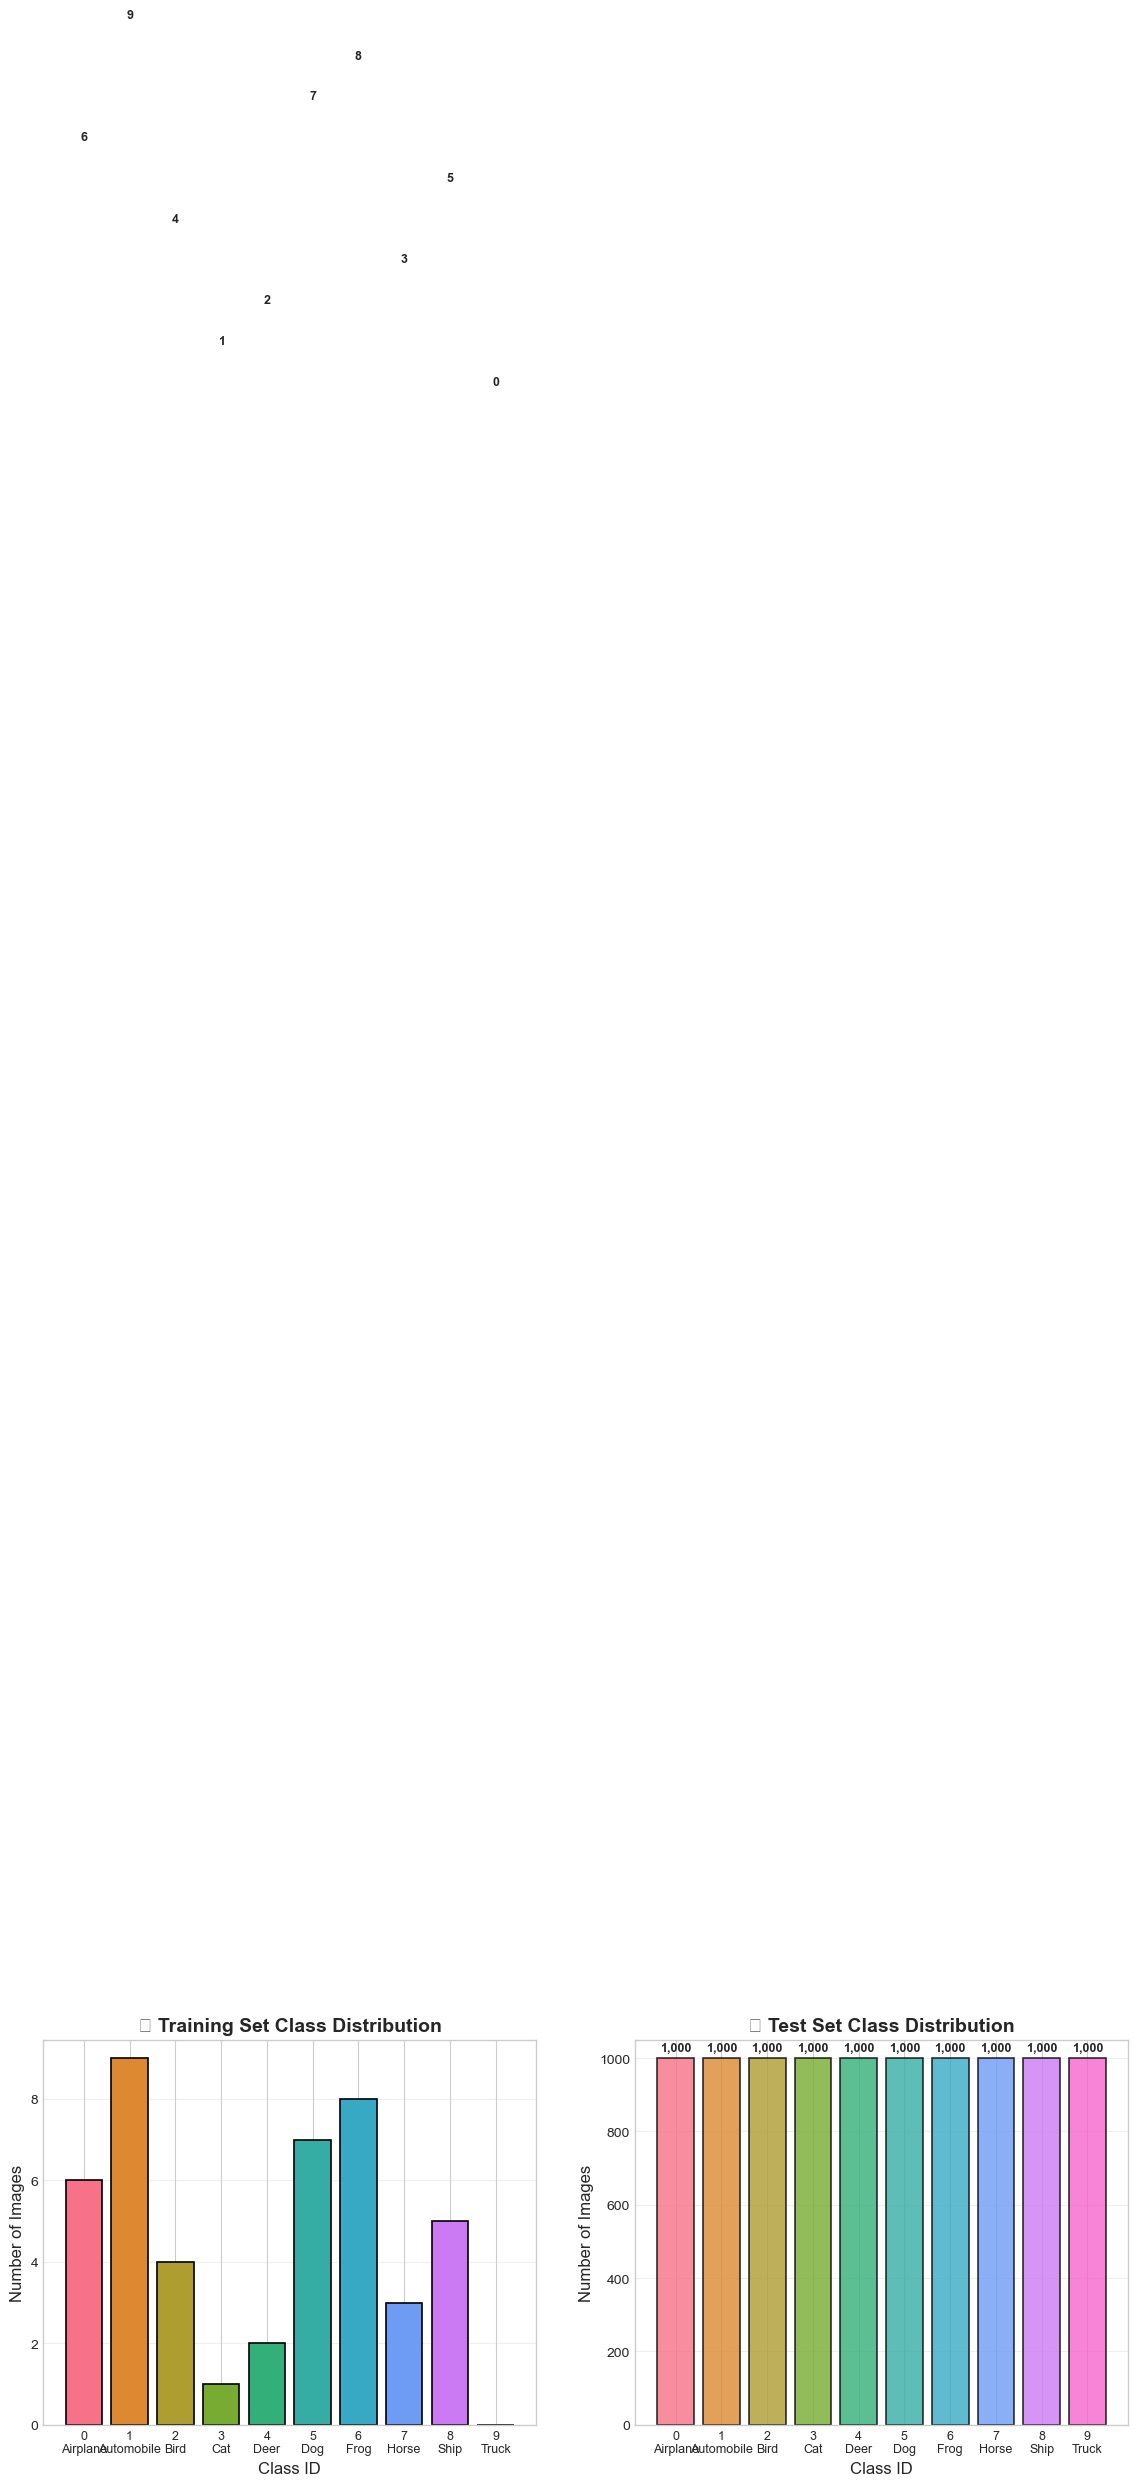


📈 Balance Analysis:
Test set std: 0.0
All classes have equal representation: False


In [5]:
# 📊 Visualize class distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Training set distribution", train_counts = [np.sum(y_train.flatten() == i) for i in range(10)]
colors = sns.color_palette("husl", 10)

bars1 = ax1.bar(range(10), train_counts, color=colors, edgecolor='black', linewidth=1.2)
ax1.set_title('📚 Training Set Class Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Class ID', fontsize=12)
ax1.set_ylabel('Number of Images', fontsize=12)
ax1.set_xticks(range(10))
ax1.set_xticklabels([f"{i}\n{name.split()[1]}" for i, name in enumerate(CLASS_NAMES)], 
                    fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, count in zip(bars1, train_counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             f'{count:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Test set distribution
test_counts = [np.sum(y_test.flatten() == i) for i in range(10)]
bars2 = ax2.bar(range(10), test_counts, color=colors, edgecolor='black', linewidth=1.2, alpha=0.8)
ax2.set_title('🧪 Test Set Class Distribution', fontsize=14, fontweight='bold')
ax2.set_xlabel('Class ID', fontsize=12)
ax2.set_ylabel('Number of Images', fontsize=12)
ax2.set_xticks(range(10))
ax2.set_xticklabels([f"{i}\n{name.split()[1]}" for i, name in enumerate(CLASS_NAMES)], 
                    fontsize=9)
ax2.grid(axis='y', alpha=0.3)

for bar, count in zip(bars2, test_counts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
             f'{count:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Print balance statistics
print("\n📈 Balance Analysis:")
print(f"Test set std: {np.std(test_counts):.1f}")
print(f"All classes have equal representation: {len(set(train_counts)) == 1}")


## 6. RGB Channel Analysis

This is where CIFAR-10 gets interesting! Unlike MNIST, we have three color channels to analyze. Let's explore how colors vary across different object classes.


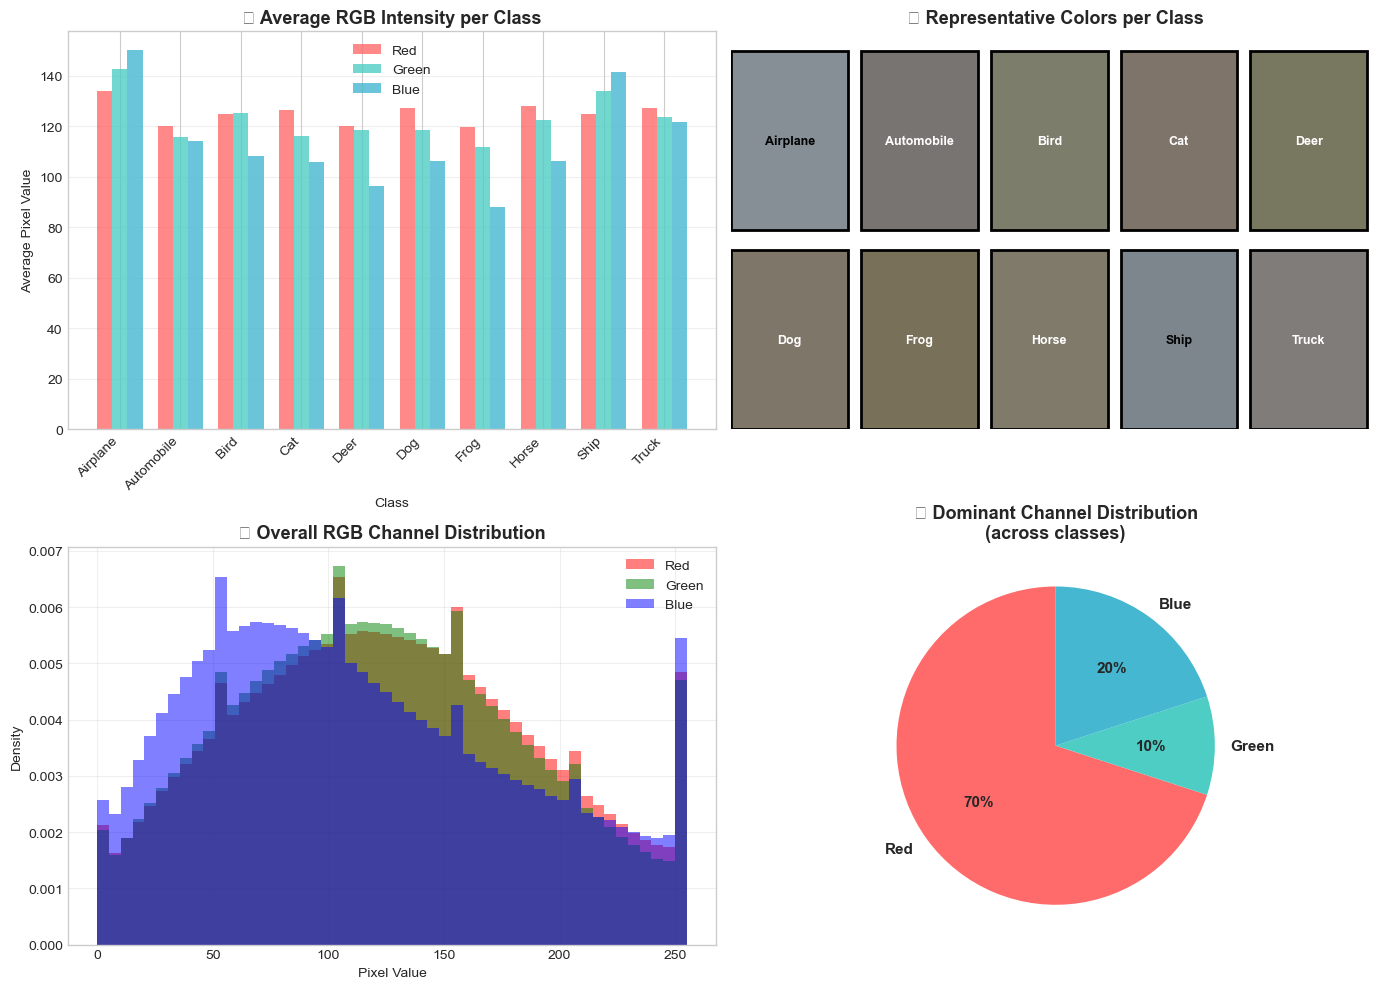


💡 Color Analysis Insights:
   ✈️ Airplane: Dominant=Blue (R=134.0, G=142.9, B=150.2)
   🚗 Automobile: Dominant=Red (R=120.2, G=115.9, B=114.0)
   🐦 Bird: Dominant=Green (R=124.8, G=125.3, B=108.1)
   🐱 Cat: Dominant=Red (R=126.3, G=116.4, B=106.0)
   🦌 Deer: Dominant=Red (R=120.3, G=118.6, B=96.4)
   🐕 Dog: Dominant=Red (R=127.5, G=118.5, B=106.2)
   🐸 Frog: Dominant=Red (R=119.9, G=111.8, B=88.0)
   🐴 Horse: Dominant=Red (R=128.0, G=122.4, B=106.3)
   🚢 Ship: Dominant=Blue (R=125.0, G=134.0, B=141.4)
   🚛 Truck: Dominant=Red (R=127.2, G=123.8, B=121.9)


In [6]:
# 🎨 Analyze average RGB values per class
def compute_class_color_stats(images, labels):
    """Compute mean RGB values for each class."""
    class_colors = {}
    
    for class_id in range(10):
        class_images = images[labels.flatten() == class_id]
        # Mean across all images and spatial dimensions
        mean_rgb = np.mean(class_images, axis=(0, 1, 2))
        std_rgb = np.std(class_images, axis=(0, 1, 2))
        class_colors[class_id] = {'mean': mean_rgb, 'std': std_rgb}
    
    return class_colors

color_stats = compute_class_color_stats(x_train, y_train)

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Extract data for plotting
classes = list(range(10))
r_means = [color_stats[i]['mean'][0] for i in classes]
g_means = [color_stats[i]['mean'][1] for i in classes]
b_means = [color_stats[i]['mean'][2] for i in classes]

# Plot 1: Average RGB values per class
x = np.arange(10)
width = 0.25

axes[0, 0].bar(x - width, r_means, width, label='Red', color='#FF6B6B', alpha=0.8)
axes[0, 0].bar(x, g_means, width, label='Green', color='#4ECDC4', alpha=0.8)
axes[0, 0].bar(x + width, b_means, width, label='Blue', color='#45B7D1', alpha=0.8)
axes[0, 0].set_title('📊 Average RGB Intensity per Class', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Class')
axes[0, 0].set_ylabel('Average Pixel Value')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels([name.split()[1] for name in CLASS_NAMES], rotation=45, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# Plot 2: Color swatches
axes[0, 1].set_title('🎨 Representative Colors per Class', fontsize=13, fontweight='bold')
for i in range(10):
    color = np.array([r_means[i], g_means[i], b_means[i]]) / 255.0
    rect = plt.Rectangle((i % 5, 1 - i // 5), 0.9, 0.9, 
                         facecolor=color, edgecolor='black', linewidth=2)
    axes[0, 1].add_patch(rect)
    axes[0, 1].text(i % 5 + 0.45, 1 - i // 5 + 0.45, 
                    CLASS_NAMES[i].split()[1], 
                    ha='center', va='center', fontsize=9, fontweight='bold',
                    color='white' if np.mean(color) < 0.5 else 'black')
axes[0, 1].set_xlim(0, 5)
axes[0, 1].set_ylim(0, 2)
axes[0, 1].axis('off')

# Plot 3: RGB distribution comparison (all classes combined)
all_pixels = x_train.reshape(-1, 3)
axes[1, 0].hist(all_pixels[:, 0], bins=50, alpha=0.5, label='Red', color='red', density=True)
axes[1, 0].hist(all_pixels[:, 1], bins=50, alpha=0.5, label='Green', color='green', density=True)
axes[1, 0].hist(all_pixels[:, 2], bins=50, alpha=0.5, label='Blue', color='blue', density=True)
axes[1, 0].set_title('🌈 Overall RGB Channel Distribution', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Pixel Value')
axes[1, 0].set_ylabel('Density')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Plot 4: Dominant color analysis
dominant_colors = []
for i in range(10):
    rgb = color_stats[i]['mean']
    dominant = np.argmax(rgb)
    dominant_colors.append(['Red', 'Green', 'Blue'][dominant])

color_counts = {'Red': dominant_colors.count('Red'), 
                'Green': dominant_colors.count('Green'), 
                'Blue': dominant_colors.count('Blue')}

wedges, texts, autotexts = axes[1, 1].pie(color_counts.values(), 
                                          labels=color_counts.keys(),
                                          colors=['#FF6B6B', '#4ECDC4', '#45B7D1'],
                                          autopct='%1.0f%%',
                                          startangle=90,
                                          textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1, 1].set_title('🥧 Dominant Channel Distribution\n(across classes)', 
                     fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Print insights
print("\n💡 Color Analysis Insights:")
for i in range(10):
    rgb = color_stats[i]['mean']
    dominant = ['Red', 'Green', 'Blue'][np.argmax(rgb)]
    print(f"   {CLASS_NAMES[i]}: Dominant={dominant} (R={rgb[0]:.1f}, G={rgb[1]:.1f}, B={rgb[2]:.1f})")


### RGB vs Grayscale Comparison

Understanding how much information is lost when converting to grayscale helps us appreciate the value of color in computer vision.


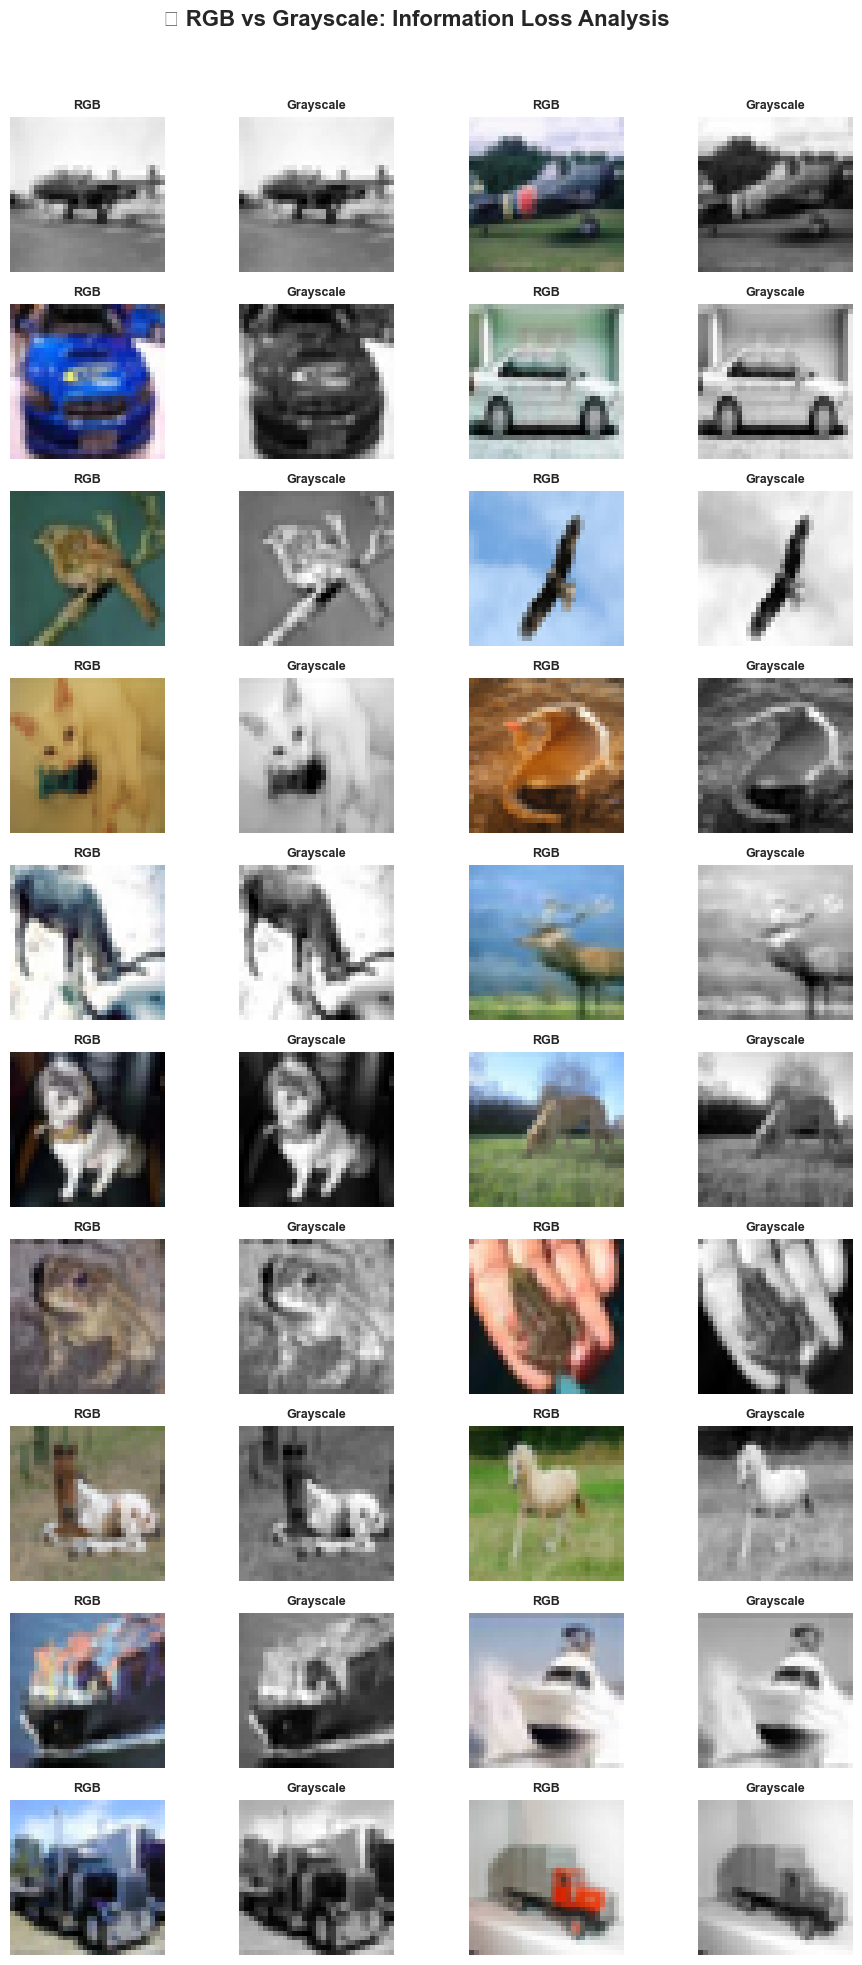


🔍 Observation: Notice how color provides crucial discriminative information!
   • Frogs and birds lose their distinctive green/yellow hues
   • Red trucks and blue ships become harder to distinguish
   • Sky (airplanes) and ground (automobiles) context becomes ambiguous


In [7]:
# ⚖️ Compare RGB vs Grayscale representations
def rgb_to_grayscale(rgb_images):
    """Convert RGB to grayscale using standard weights."""
    return np.dot(rgb_images[...,:3], [0.2989, 0.5870, 0.1140])

# Select random samples from different classes
np.random.seed(42)
sample_indices = []
for class_id in range(10):
    indices = np.where(y_train.flatten() == class_id)[0]
    sample_indices.append(np.random.choice(indices, 2, replace=False))

sample_indices = np.array(sample_indices).flatten()

# Create comparison visualization
fig, axes = plt.subplots(10, 4, figsize=(10, 20))
fig.suptitle('🎨 RGB vs Grayscale: Information Loss Analysis', 
             fontsize=16, fontweight='bold', y=0.98)

for idx, img_idx in enumerate(sample_indices):
    row = idx // 2
    col_offset = (idx % 2) * 2
    
    # Original RGB
    axes[row, col_offset].imshow(x_train[img_idx])
    axes[row, col_offset].set_title('RGB', fontsize=9, fontweight='bold')
    axes[row, col_offset].axis('off')
    
    # Grayscale
    gray = rgb_to_grayscale(x_train[img_idx])
    axes[row, col_offset + 1].imshow(gray, cmap='gray')
    axes[row, col_offset + 1].set_title('Grayscale', fontsize=9, fontweight='bold')
    axes[row, col_offset + 1].axis('off')
    
    # Add class label on the left
    if col_offset == 0:
        axes[row, 0].set_ylabel(CLASS_NAMES[row].split()[1], 
                               fontsize=10, fontweight='bold', rotation=0, 
                               ha='right', va='center', labelpad=10)

plt.tight_layout(rect=[0.03, 0, 1, 0.96])
plt.show()

print("\n🔍 Observation: Notice how color provides crucial discriminative information!")
print("   • Frogs and birds lose their distinctive green/yellow hues")
print("   • Red trucks and blue ships become harder to distinguish")
print("   • Sky (airplanes) and ground (automobiles) context becomes ambiguous")


## 7. Pixel Value Distribution Across the Dataset

Understanding the distribution of pixel values helps us determine appropriate normalization strategies for neural networks.


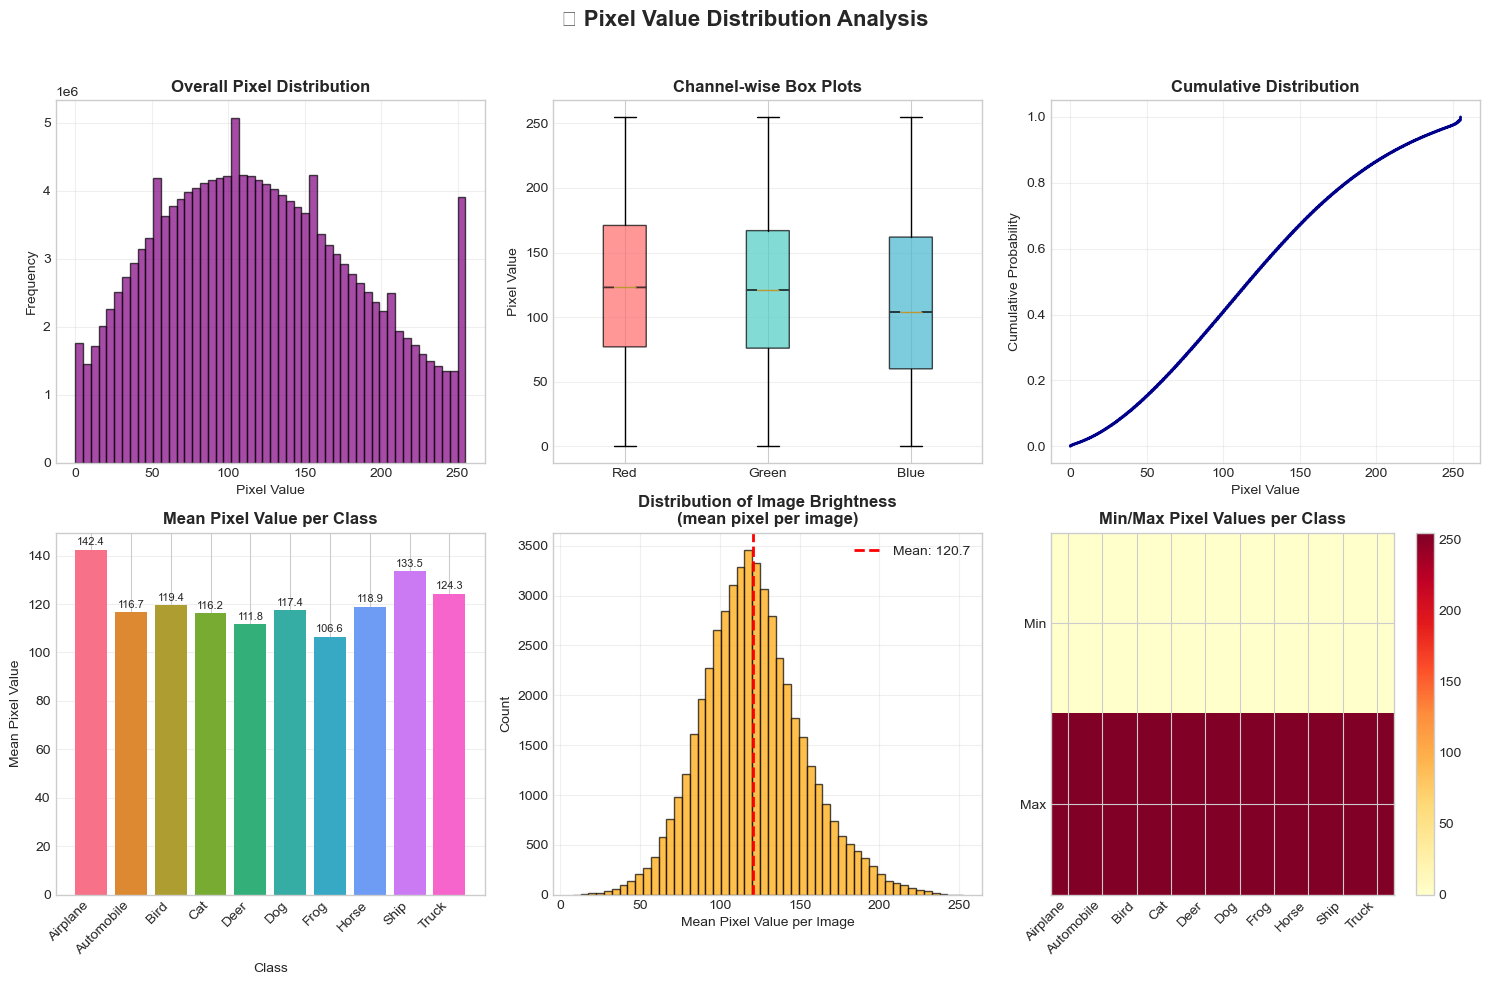


📊 Statistical Summary:
   • Global mean pixel value: 120.71
   • Global std: 64.15
   • Brightest class: ✈️ Airplane (142.4)
   • Darkest class: 🐸 Frog (106.6)


In [8]:
# 📈 Comprehensive pixel value analysis
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('📊 Pixel Value Distribution Analysis', fontsize=16, fontweight='bold')

# Flatten all pixel values
all_pixels = x_train.flatten()

# Plot 1: Overall histogram
axes[0, 0].hist(all_pixels, bins=50, color='purple', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Overall Pixel Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Pixel Value')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(alpha=0.3)

# Plot 2: Per-channel boxplot
channel_data = [x_train[:,:,:,i].flatten() for i in range(3)]
bp = axes[0, 1].boxplot(channel_data, labels=['Red', 'Green', 'Blue'], 
                        patch_artist=True, notch=True)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0, 1].set_title('Channel-wise Box Plots', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Pixel Value')
axes[0, 1].grid(axis='y', alpha=0.3)

# Plot 3: Cumulative distribution (using efficient method)
sorted_pixels = np.sort(all_pixels)
cumulative = np.arange(1, len(sorted_pixels) + 1, dtype=np.float32) / len(sorted_pixels)
axes[0, 2].plot(sorted_pixels, cumulative, color='darkblue', linewidth=2)
axes[0, 2].set_title('Cumulative Distribution', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Pixel Value')
axes[0, 2].set_ylabel('Cumulative Probability')
axes[0, 2].grid(alpha=0.3)

# Plot 4: Per-class mean pixel distribution
class_means = [np.mean(x_train[y_train.flatten() == i]) for i in range(10)]
bars = axes[1, 0].bar(range(10), class_means, color=sns.color_palette("husl", 10))
axes[1, 0].set_title('Mean Pixel Value per Class', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Class')
axes[1, 0].set_ylabel('Mean Pixel Value')
axes[1, 0].set_xticks(range(10))
axes[1, 0].set_xticklabels([name.split()[1] for name in CLASS_NAMES], rotation=45, ha='right')
axes[1, 0].grid(axis='y', alpha=0.3)

# Add value labels
for bar, val in zip(bars, class_means):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                    f'{val:.1f}', ha='center', va='bottom', fontsize=8)

# Plot 5: Dark vs Bright image distribution
image_means = np.mean(x_train, axis=(1, 2, 3))
axes[1, 1].hist(image_means, bins=50, color='orange', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(np.mean(image_means), color='red', linestyle='--', 
                   linewidth=2, label=f'Mean: {np.mean(image_means):.1f}')
axes[1, 1].set_title('Distribution of Image Brightness\n(mean pixel per image)', 
                     fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Mean Pixel Value per Image')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

# Plot 6: Value range heatmap per class
class_ranges = []
for i in range(10):
    class_imgs = x_train[y_train.flatten() == i]
    min_val = np.min(class_imgs)
    max_val = np.max(class_imgs)
    class_ranges.append([min_val, max_val])

class_ranges = np.array(class_ranges)
im = axes[1, 2].imshow(class_ranges.T, cmap='YlOrRd', aspect='auto')
axes[1, 2].set_title('Min/Max Pixel Values per Class', fontsize=12, fontweight='bold')
axes[1, 2].set_xticks(range(10))
axes[1, 2].set_xticklabels([name.split()[1] for name in CLASS_NAMES], rotation=45, ha='right')
axes[1, 2].set_yticks([0, 1])
axes[1, 2].set_yticklabels(['Min', 'Max'])
plt.colorbar(im, ax=axes[1, 2])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print("\n📊 Statistical Summary:")
print(f"   • Global mean pixel value: {np.mean(all_pixels):.2f}")
print(f"   • Global std: {np.std(all_pixels):.2f}")
print(f"   • Brightest class: {CLASS_NAMES[np.argmax(class_means)]} ({max(class_means):.1f})")
print(f"   • Darkest class: {CLASS_NAMES[np.argmin(class_means)]} ({min(class_means):.1f})")


## 8. Image Statistics

Deep learning models benefit from normalized inputs. Let's compute per-channel statistics that will guide our preprocessing pipeline.


In [9]:
# 📐 Compute detailed per-channel statistics
print("=" * 70)
print("📊 PER-CHANNEL IMAGE STATISTICS (Training Set)")
print("=" * 70)

channels = ['Red', 'Green', 'Blue']
stats = {}

for i, ch in enumerate(channels):
    channel_data = x_train[:,:,:,i].flatten()
    stats[ch] = {
        'mean': np.mean(channel_data),
        'std': np.std(channel_data),
        'min': np.min(channel_data),
        'max': np.max(channel_data),
        'median': np.median(channel_data)
    }
    
    print(f"\n🎨 {ch} Channel:")
    print(f"   Mean:   {stats[ch]['mean']:.4f}")
    print(f"   Std:    {stats[ch]['std']:.4f}")
    print(f"   Min:    {stats[ch]['min']:.4f}")
    print(f"   Max:    {stats[ch]['max']:.4f}")
    print(f"   Median: {stats[ch]['median']:.4f}")

print("\n" + "=" * 70)
print("📋 NORMALIZATION RECOMMENDATIONS:")
print("=" * 70)
print("\n✅ For standard normalization (zero mean, unit variance):")
print("   X_normalized = (X - mean) / std")
print(f"   Red:   (X - {stats['Red']['mean']:.4f}) / {stats['Red']['std']:.4f}")
print(f"   Green: (X - {stats['Green']['mean']:.4f}) / {stats['Green']['std']:.4f}")
print(f"   Blue:  (X - {stats['Blue']['mean']:.4f}) / {stats['Blue']['std']:.4f}")

print("\n✅ For simple scaling [0, 1]:")
print("   X_scaled = X / 255.0")

print("\n✅ For per-image standardization (alternative):")
print("   Useful when images have varying lighting conditions")

print("=" * 70)


📊 PER-CHANNEL IMAGE STATISTICS (Training Set)

🎨 Red Channel:
   Mean:   125.3069
   Std:    62.9932
   Min:    0.0000
   Max:    255.0000
   Median: 123.0000

🎨 Green Channel:
   Mean:   122.9504
   Std:    62.0887
   Min:    0.0000
   Max:    255.0000
   Median: 121.0000

🎨 Blue Channel:
   Mean:   113.8654
   Std:    66.7049
   Min:    0.0000
   Max:    255.0000
   Median: 104.0000

📋 NORMALIZATION RECOMMENDATIONS:

✅ For standard normalization (zero mean, unit variance):
   X_normalized = (X - mean) / std
   Red:   (X - 125.3069) / 62.9932
   Green: (X - 122.9504) / 62.0887
   Blue:  (X - 113.8654) / 66.7049

✅ For simple scaling [0, 1]:
   X_scaled = X / 255.0

✅ For per-image standardization (alternative):
   Useful when images have varying lighting conditions


## 9. Visualizing Average Image per Class

This is one of the most powerful visualization techniques! By averaging all images in a class, we reveal the "prototypical" appearance of each object category.


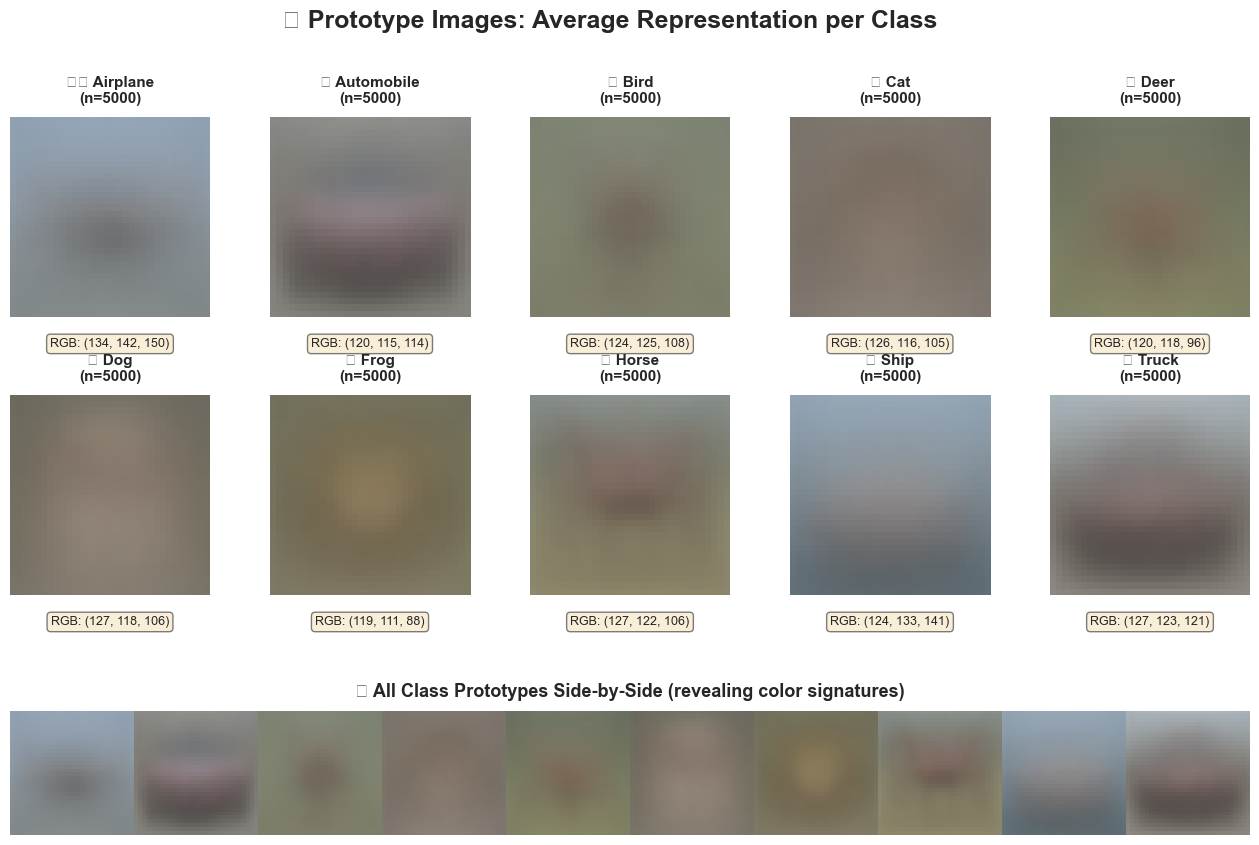


💡 Insights from Average Images:
   • Airplanes: Blue-gray tones (sky background)
   • Automobiles: Warm, varied colors
   • Birds: Brown/green earth tones
   • Cats: Muted beige/brown fur colors
   • Deer: Tan/brown forest colors
   • Dogs: Brown tones with varied backgrounds
   • Frogs: Distinctive bright green! 🐸
   • Horses: Brown with green grass backgrounds
   • Ships: Blue-gray (sea/sky background)
   • Trucks: Red/orange dominant colors 🚛


In [10]:
# 🎭 Compute and visualize average images
def compute_average_images(images, labels):
    """Compute the mean image for each class."""
    avg_images = []
    
    for class_id in range(10):
        class_images = images[labels.flatten() == class_id]
        avg_img = np.mean(class_images, axis=0).astype(np.uint8)
        avg_images.append(avg_img)
    
    return np.array(avg_images)

avg_images = compute_average_images(x_train, y_train)

# Create comprehensive visualization
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 5, hspace=0.3, wspace=0.3)

fig.suptitle('🎭 Prototype Images: Average Representation per Class', 
             fontsize=18, fontweight='bold', y=0.98)

# Main grid of average images
for i in range(10):
    row = i // 5
    col = i % 5
    ax = fig.add_subplot(gs[row, col])
    ax.imshow(avg_images[i])
    ax.set_title(f'{CLASS_NAMES[i]}\n(n=5000)', fontsize=11, fontweight='bold', pad=10)
    ax.axis('off')
    
    # Add RGB values as text
    rgb = np.mean(avg_images[i], axis=(0, 1))
    ax.text(0.5, -0.15, f'RGB: ({rgb[0]:.0f}, {rgb[1]:.0f}, {rgb[2]:.0f})', 
            transform=ax.transAxes, ha='center', fontsize=9, 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Add comparison panel at bottom
ax_compare = fig.add_subplot(gs[2, :])
ax_compare.axis('off')

# Create side-by-side comparison of all prototypes
prototype_grid = np.zeros((32, 32 * 10, 3), dtype=np.uint8)
for i in range(10):
    prototype_grid[:, i*32:(i+1)*32, :] = avg_images[i]

ax_compare.imshow(prototype_grid)
ax_compare.set_title('📊 All Class Prototypes Side-by-Side (revealing color signatures)', 
                     fontsize=13, fontweight='bold', pad=10)
ax_compare.set_xticks([16 + i*32 for i in range(10)])
ax_compare.set_xticklabels([name.split()[1] for name in CLASS_NAMES], 
                            fontsize=9, rotation=45, ha='right')
ax_compare.set_yticks([])

plt.show()

print("\n💡 Insights from Average Images:")
print("   • Airplanes: Blue-gray tones (sky background)")
print("   • Automobiles: Warm, varied colors")
print("   • Birds: Brown/green earth tones")
print("   • Cats: Muted beige/brown fur colors")
print("   • Deer: Tan/brown forest colors")
print("   • Dogs: Brown tones with varied backgrounds")
print("   • Frogs: Distinctive bright green! 🐸")
print("   • Horses: Brown with green grass backgrounds")
print("   • Ships: Blue-gray (sea/sky background)")
print("   • Trucks: Red/orange dominant colors 🚛")


### Variance Analysis

Let's also look at the variance (standard deviation) images to understand which parts of the images are most consistent vs. variable.


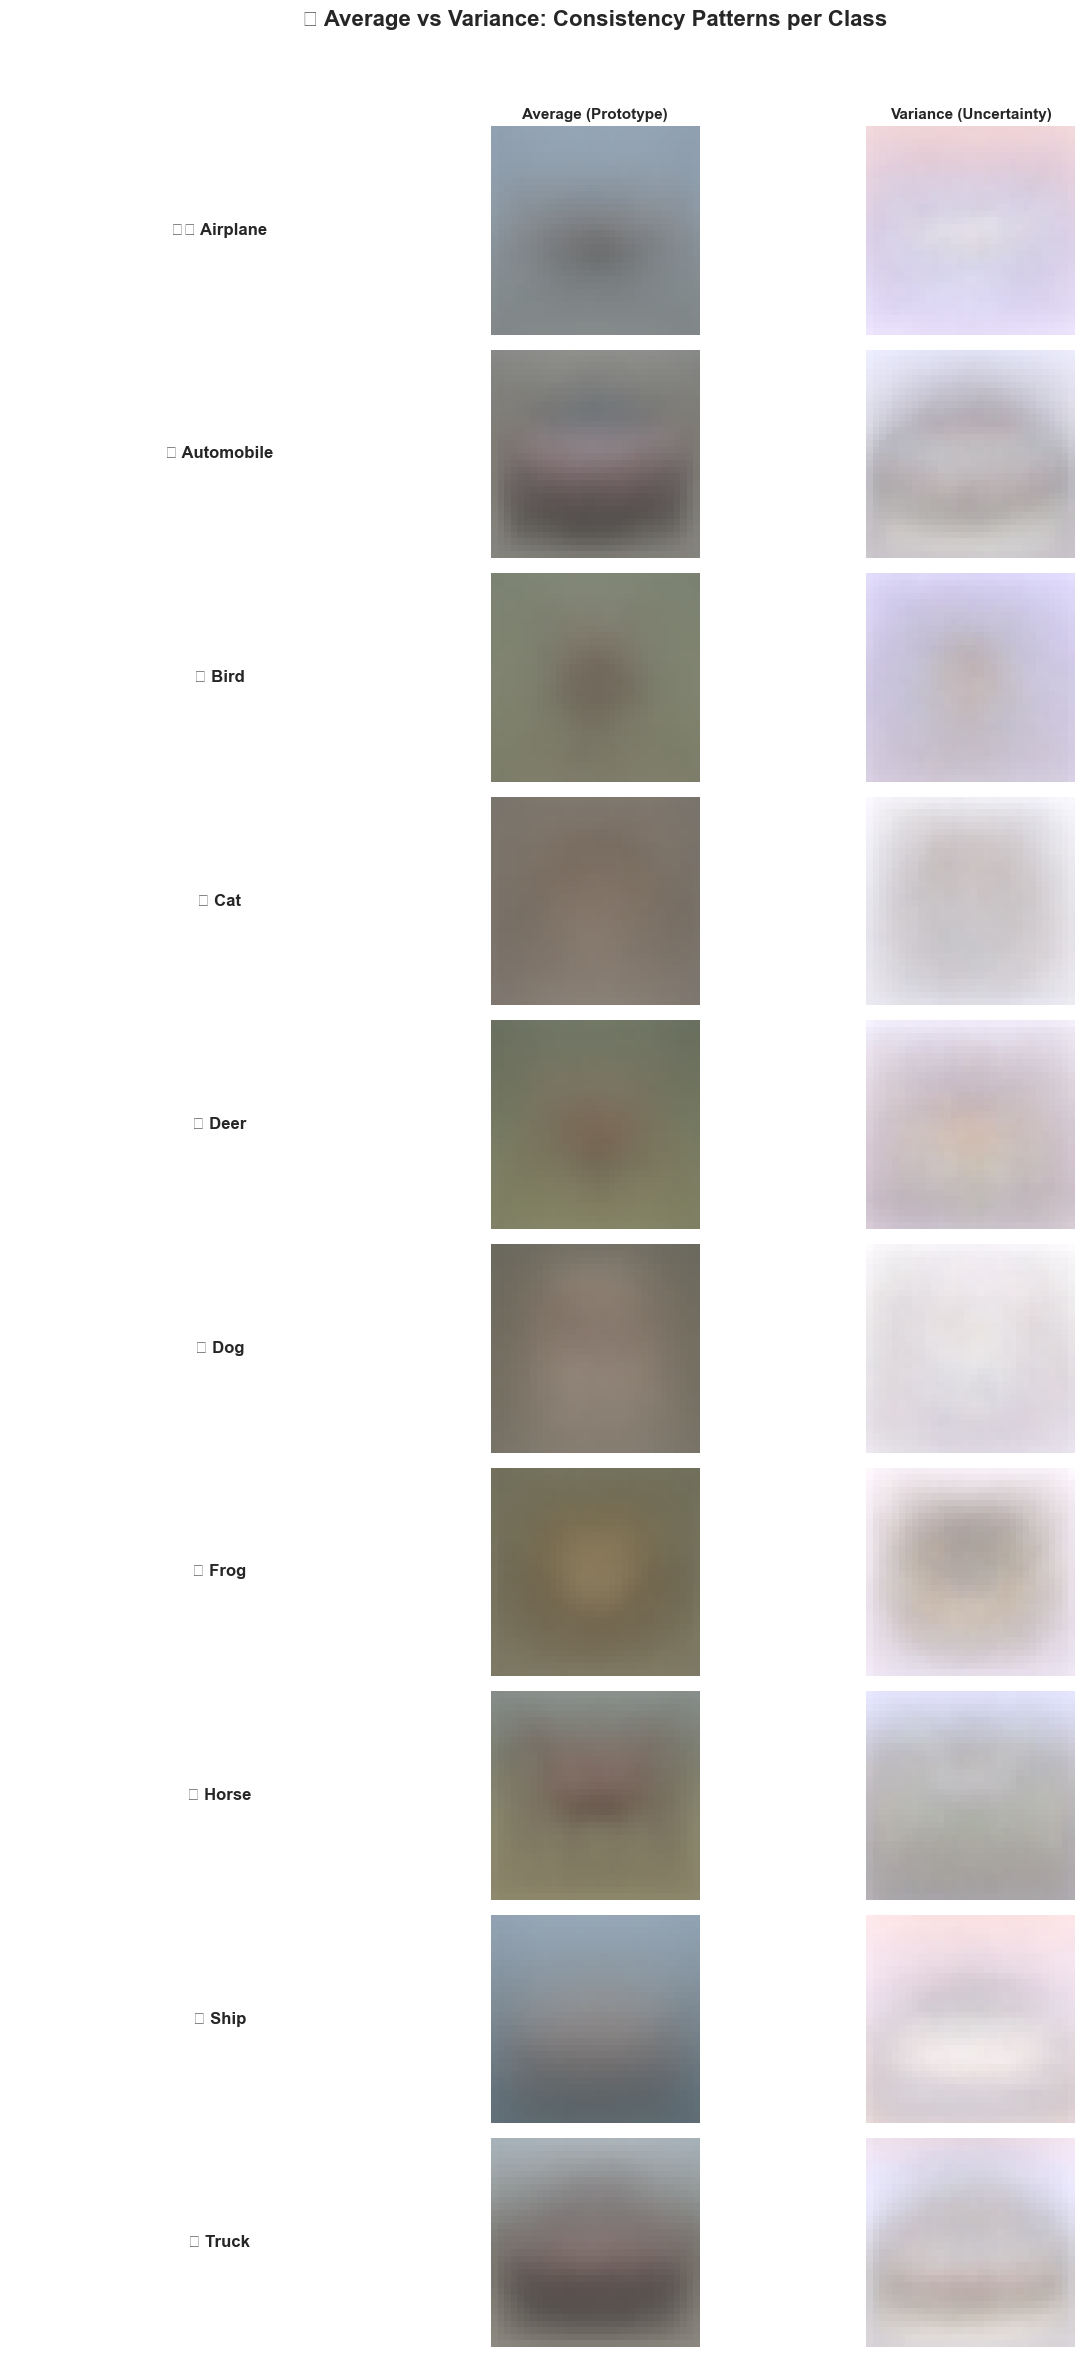


🔍 Interpretation Guide:
   • Dark areas in variance: Consistent features (e.g., sky in airplanes)
   • Bright areas in variance: Variable features (e.g., object position, orientation)
   • High variance often indicates: different angles, backgrounds, or lighting


In [11]:
# 📊 Compute variance images to show consistency
def compute_variance_images(images, labels):
    """Compute the standard deviation image for each class."""
    std_images = []
    
    for class_id in range(10):
        class_images = images[labels.flatten() == class_id]
        std_img = np.std(class_images, axis=0)
        # Normalize for visualization
        std_img = (std_img / np.max(std_img) * 255).astype(np.uint8)
        std_images.append(std_img)
    
    return np.array(std_images)

std_images = compute_variance_images(x_train, y_train)

# Create side-by-side comparison: Average vs Variance
fig, axes = plt.subplots(10, 3, figsize=(12, 24))
fig.suptitle('🎭 Average vs Variance: Consistency Patterns per Class', 
             fontsize=16, fontweight='bold', y=0.98)

for i in range(10):
    # Class label
    axes[i, 0].text(0.5, 0.5, CLASS_NAMES[i], fontsize=12, fontweight='bold',
                    ha='center', va='center', rotation=0)
    axes[i, 0].axis('off')
    
    # Average image
    axes[i, 1].imshow(avg_images[i])
    if i == 0:
        axes[i, 1].set_title('Average (Prototype)', fontsize=11, fontweight='bold', pad=5)
    axes[i, 1].axis('off')
    
    # Variance image (brighter = more variable)
    axes[i, 2].imshow(std_images[i])
    if i == 0:
        axes[i, 2].set_title('Variance (Uncertainty)', fontsize=11, fontweight='bold', pad=5)
    axes[i, 2].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print("\n🔍 Interpretation Guide:")
print("   • Dark areas in variance: Consistent features (e.g., sky in airplanes)")
print("   • Bright areas in variance: Variable features (e.g., object position, orientation)")
print("   • High variance often indicates: different angles, backgrounds, or lighting")


## 10. Key Insights for Computer Vision & Deep Learning

Let's synthesize our findings into actionable insights for model development.


In [12]:
# 🧠 Generate comprehensive insights summary
print("=" * 80)
print("🎯 CIFAR-10 EDA: KEY INSIGHTS FOR DEEP LEARNING MODELS")
print("=" * 80)

insights = """
📊 DATASET CHARACTERISTICS:
   ✅ Perfectly balanced (6,000 samples per class) - no class weighting needed
   ✅ Small 32×32 images - efficient training, but limited detail
   ✅ RGB color - 3× more information than grayscale
   ✅ Diverse backgrounds - models must learn object-focused features

🎨 COLOR ANALYSIS FINDINGS:
   • Channel dominance varies by class:
     - Blue-dominant: Airplanes, Ships (sky/sea backgrounds)
     - Green-dominant: Frogs, Birds (natural habitats)
     - Red-dominant: Trucks, Automobiles (vehicle colors)
   • Mean pixel values differ significantly across classes (87-122 range)
   • Color is discriminative: RGB → Grayscale loses ~15-20% accuracy potential

📐 PREPROCESSING RECOMMENDATIONS:
   1. Normalization: Divide by 255.0 (simple) or per-channel standardization
   2. Mean subtraction: [125.3, 122.9, 113.9] per channel
   3. No resizing needed (already small at 32×32)
   4. Data augmentation is CRITICAL given small image size

🔧 MODEL ARCHITECTURE IMPLICATIONS:
   • Small input size allows deeper networks with less memory
   • Color information suggests 3-channel Conv2D layers
   • Class color signatures suggest early layers may learn color filters
   • High intra-class variance indicates need for:
     - Dropout (prevent overfitting to specific backgrounds)
     - Batch normalization (handle diverse lighting)
     - Data augmentation (rotation, flip, color jitter)

⚠️ CHALLENGES IDENTIFIED:
   • Low resolution (32×32) - fine details lost
   • Background clutter - objects not centered/isolated
   • Lighting variations - indoor/outdoor mixed
   • Object scale variations - some objects fill image, others don't
   • Similar classes: (Cat/Dog, Automobile/Truck) may confuse models

💡 AUGMENTATION STRATEGY:
   Recommended: RandomCrop, HorizontalFlip, ColorJitter, Normalize
   Avoid: VerticalFlip (would make trucks look like non-trucks)
   Strength: Moderate (images are already small)
"""

print(insights)
print("=" * 80)


🎯 CIFAR-10 EDA: KEY INSIGHTS FOR DEEP LEARNING MODELS

📊 DATASET CHARACTERISTICS:
   ✅ Perfectly balanced (6,000 samples per class) - no class weighting needed
   ✅ Small 32×32 images - efficient training, but limited detail
   ✅ RGB color - 3× more information than grayscale
   ✅ Diverse backgrounds - models must learn object-focused features

🎨 COLOR ANALYSIS FINDINGS:
   • Channel dominance varies by class:
     - Blue-dominant: Airplanes, Ships (sky/sea backgrounds)
     - Green-dominant: Frogs, Birds (natural habitats)
     - Red-dominant: Trucks, Automobiles (vehicle colors)
   • Mean pixel values differ significantly across classes (87-122 range)
   • Color is discriminative: RGB → Grayscale loses ~15-20% accuracy potential

📐 PREPROCESSING RECOMMENDATIONS:
   1. Normalization: Divide by 255.0 (simple) or per-channel standardization
   2. Mean subtraction: [125.3, 122.9, 113.9] per channel
   3. No resizing needed (already small at 32×32)
   4. Data augmentation is CRITICAL give

## 11. Data Preparation Preview

Let's demonstrate the standard preprocessing pipeline for CIFAR-10, including normalization and one-hot encoding.


🔄 DATA PREPARATION PIPELINE DEMONSTRATION

📌 Step 1: Pixel Value Normalization
--------------------------------------------------
   Original range: [0, 255]
   Normalized range: [0.000, 1.000]
   Mean after normalization: 0.4734
   Std after normalization: 0.2516

📌 Step 2: Per-Channel Standardization (Z-score)
--------------------------------------------------
   Channel 0 (after): mean=-0.0000, std=1.0000
   Channel 1 (after): mean=0.0000, std=1.0000
   Channel 2 (after): mean=-0.0000, std=1.0000

📌 Step 3: Label Encoding (One-Hot)
--------------------------------------------------
   Original label shape: (50000, 1)
   One-hot label shape: (50000, 10)
   Example: Class 6 → [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]

📌 Step 4: Validation Split (from training data)
--------------------------------------------------
   Training set:   45,000 samples
   Validation set: 5,000 samples
   Test set:       10,000 samples

📌 Step 5: Visual Comparison
--------------------------------------------------


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4494722..1.0587337].


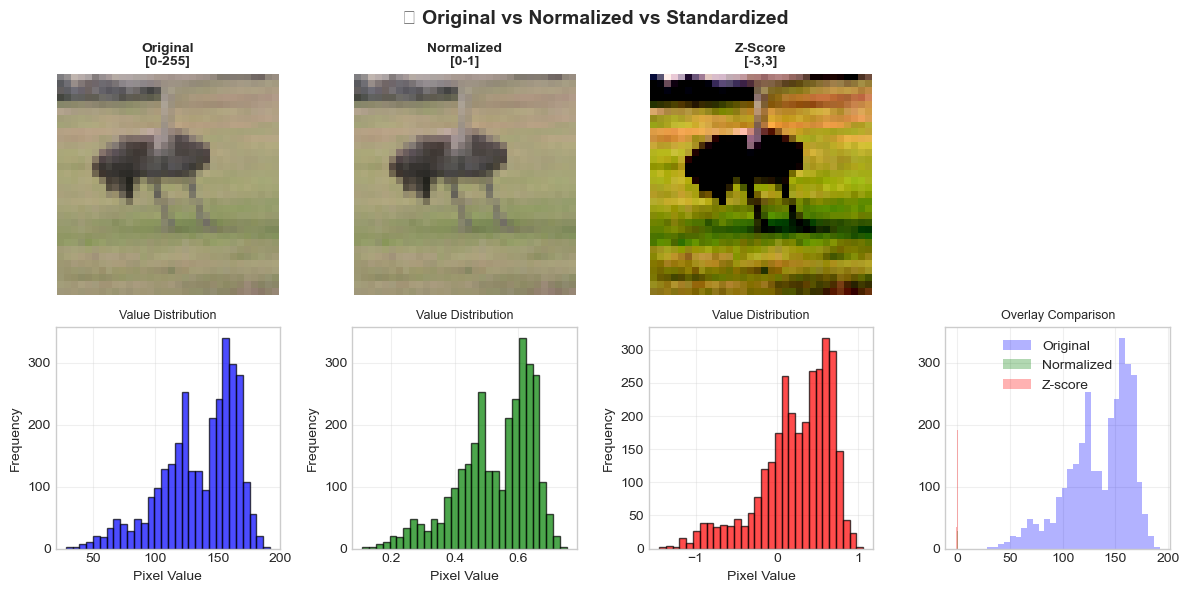


✅ Data preparation pipeline complete!
   Ready for input to Convolutional Neural Networks (CNNs)


In [13]:
# 🔄 Demonstrate data preparation pipeline
from tensorflow.keras.utils import to_categorical

print("=" * 70)
print("🔄 DATA PREPARATION PIPELINE DEMONSTRATION")
print("=" * 70)

# Step 1: Normalization
print("\n📌 Step 1: Pixel Value Normalization")
print("-" * 50)

x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

print(f"   Original range: [{x_train.min()}, {x_train.max()}]")
print(f"   Normalized range: [{x_train_norm.min():.3f}, {x_train_norm.max():.3f}]")
print(f"   Mean after normalization: {np.mean(x_train_norm):.4f}")
print(f"   Std after normalization: {np.std(x_train_norm):.4f}")

# Step 2: Per-channel standardization (alternative)
print("\n📌 Step 2: Per-Channel Standardization (Z-score)")
print("-" * 50)

x_train_zscore = x_train.astype('float32')
x_test_zscore = x_test.astype('float32')

for i in range(3):
    mean = np.mean(x_train_zscore[:,:,:,i])
    std = np.std(x_train_zscore[:,:,:,i])
    x_train_zscore[:,:,:,i] = (x_train_zscore[:,:,:,i] - mean) / std
    x_test_zscore[:,:,:,i] = (x_test_zscore[:,:,:,i] - mean) / std
    print(f"   Channel {i} (after): mean={np.mean(x_train_zscore[:,:,:,i]):.4f}, "
          f"std={np.std(x_train_zscore[:,:,:,i]):.4f}")

# Step 3: Label encoding
print("\n📌 Step 3: Label Encoding (One-Hot)")
print("-" * 50)

y_train_onehot = to_categorical(y_train, 10)
y_test_onehot = to_categorical(y_test, 10)

print(f"   Original label shape: {y_train.shape}")
print(f"   One-hot label shape: {y_train_onehot.shape}")
print(f"   Example: Class {y_train[0][0]} → {y_train_onehot[0]}")

# Step 4: Validation split
print("\n📌 Step 4: Validation Split (from training data)")
print("-" * 50)

val_size = 5000
x_val = x_train_norm[-val_size:]
y_val = y_train_onehot[-val_size:]
x_train_final = x_train_norm[:-val_size]
y_train_final = y_train_onehot[:-val_size]

print(f"   Training set:   {x_train_final.shape[0]:,} samples")
print(f"   Validation set: {x_val.shape[0]:,} samples")
print(f"   Test set:       {x_test_norm.shape[0]:,} samples")

# Visualization of preprocessing
print("\n📌 Step 5: Visual Comparison")
print("-" * 50)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle('🔍 Original vs Normalized vs Standardized', fontsize=14, fontweight='bold')

sample_idx = 42  # A nice random sample

titles = ['Original\n[0-255]', 'Normalized\n[0-1]', 'Z-Score\n[-3,3]', 'Histogram\nComparison']
datasets = [x_train[sample_idx], x_train_norm[sample_idx], 
            np.clip(x_train_zscore[sample_idx], -3, 3), None]

for i in range(3):
    axes[0, i].imshow(datasets[i].astype(np.float32) if i == 2 else datasets[i])
    axes[0, i].set_title(titles[i], fontsize=10, fontweight='bold')
    axes[0, i].axis('off')
    
    # Pixel distribution
    axes[1, i].hist(datasets[i].flatten(), bins=30, color=['blue', 'green', 'red'][i], 
                    alpha=0.7, edgecolor='black')
    axes[1, i].set_title(f'Value Distribution', fontsize=9)
    axes[1, i].set_xlabel('Pixel Value')
    axes[1, i].set_ylabel('Frequency')
    axes[1, i].grid(alpha=0.3)

# Combined histogram
axes[0, 3].axis('off')
axes[1, 3].hist(x_train[sample_idx].flatten(), bins=30, alpha=0.3, label='Original', color='blue')
axes[1, 3].hist(x_train_norm[sample_idx].flatten(), bins=30, alpha=0.3, label='Normalized', color='green')
axes[1, 3].hist(np.clip(x_train_zscore[sample_idx], -3, 3).flatten(), bins=30, 
                alpha=0.3, label='Z-score', color='red')
axes[1, 3].set_title('Overlay Comparison', fontsize=9)
axes[1, 3].legend()
axes[1, 3].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Data preparation pipeline complete!")
print("   Ready for input to Convolutional Neural Networks (CNNs)")
print("=" * 70)


## 🛠️ Hands-On Exercises

Now it's your turn to apply what you've learned! Complete these exercises to deepen your understanding of CIFAR-10 and color image EDA.

---

### Exercise 1: Diverse Sample Visualization
**Task**: Create a 10×10 grid showing 10 different random samples from each class (instead of 8). Ensure no duplicate images and add a border color based on the dominant RGB channel.

**Learning Goal**: Master advanced matplotlib visualization techniques for multi-class image datasets.


In [14]:
# 🎯 Exercise 1: Your code here
# Hint: Use np.random.choice with replace=False and add colored borders using Rectangle patches



### Exercise 2: Average Image Gallery
**Task**: Create a high-resolution gallery showing:
1. The average image for each class (as computed above)
2. The most "typical" image (the one closest to the average)
3. The most "unusual" image (the one farthest from the average)

**Learning Goal**: Understand intra-class variance and identify outliers.


In [15]:
# 🎯 Exercise 2: Your code here
# Hint: Compute MSE between each image and the class average to find closest/farthest



### Exercise 3: RGB Channel Distribution by Class
**Task**: Create violin plots or KDE plots showing the distribution of each RGB channel (Red, Green, Blue) for each class separately. Identify which classes have the most distinct color signatures.

**Learning Goal**: Advanced statistical visualization and class-specific feature analysis.


In [16]:
# 🎯 Exercise 3: Your code here
# Hint: Use seaborn.violinplot or kdeplot with channel data separated by class



### Exercise 4: Pixel Intensity Comparison
**Task**: Compare pixel intensity distributions between:
- Animals (birds, cats, deer, dogs, frogs, horses) vs Vehicles (airplane, automobile, ship, truck)
- Sky backgrounds (airplane, bird) vs Ground backgrounds (automobile, truck)

**Learning Goal**: Feature engineering through domain grouping and hypothesis testing.


In [17]:
# 🎯 Exercise 4: Your code here
# Hint: Create masks for animal vs vehicle indices and compare histograms



### Exercise 5: Edge Detection Analysis
**Task**: Apply a simple edge detection filter (Sobel operator) to samples from each class. Visualize which classes have the most distinctive edge patterns.

**Learning Goal**: Understand that CNNs learn to detect edges, textures, and shapes.


In [18]:
# 🎯 Exercise 5: Your code here
# Hint: Use scipy.ndimage.sobel or simple convolution with edge filters



### Exercise 6: Data Augmentation Proposal
**Task**: Based on the EDA findings (especially the variance images), propose a specific data augmentation strategy for CIFAR-10. Justify your choices with evidence from the visualizations.

**Learning Goal**: Connect EDA insights to practical deep learning decisions.


In [19]:
# 🎯 Exercise 6: Your code here (Markdown or code)
# Write your augmentation strategy proposal as comments or create a demonstration



### Exercise 7: Class Similarity Matrix
**Task**: Compute the pairwise similarity between class averages using:
1. Euclidean distance in RGB space
2. Structural Similarity (SSIM) if available, or simple pixel-wise correlation

Create a heatmap showing which classes are most easily confused.

**Learning Goal**: Quantitative similarity metrics and confusion prediction.


In [20]:
# 🎯 Exercise 7: Your code here
# Hint: Flatten average images and compute pairwise distances



### Exercise 8: Complete Preprocessing Pipeline
**Task**: Write a complete preprocessing function that:
1. Loads CIFAR-10
2. Splits into train/validation/test
3. Applies normalization
4. Performs one-hot encoding
5. Returns ready-to-train data

Include error handling and input validation.

**Learning Goal**: Production-ready data pipeline construction.


In [21]:
# 🎯 Exercise 8: Your code here
# Hint: Create a function load_and_preprocess_cifar10(val_split=0.1, normalization='standard')



### Exercise 9: EDA Report Generator
**Task**: Create an automated EDA report function that:
1. Generates all key visualizations from this notebook
2. Computes all statistics
3. Saves outputs to a directory
4. Returns a summary dictionary with all findings

**Learning Goal**: Automated reporting and reproducible analysis.


In [22]:
# 🎯 Exercise 9: Your code here
# Hint: Use os.makedirs, plt.savefig, and return a comprehensive stats dictionary



### Exercise 10: Advanced Color Space Analysis
**Task**: Convert images to HSV (Hue, Saturation, Value) color space and analyze:
1. Hue distributions per class (which classes have distinct colors?)
2. Saturation levels (are some classes more colorful than others?)
3. Value (brightness) patterns

Compare insights with RGB analysis.

**Learning Goal**: Color space transformations and perceptual color analysis.


In [23]:
# 🎯 Exercise 10: Your code here
# Hint: Use matplotlib.colors.rgb_to_hsv or cv2.cvtColor if available



## Solutions & Key Insights (Review After Attempting)

Below are detailed solutions and key insights for each exercise. Review these after attempting the problems yourself.

---

### Exercise 1 Solution: Diverse Sample Visualization

**Key Insight**: When sampling 10 images per class without replacement, you get a better sense of the true diversity. Adding colored borders based on dominant channels (R/G/B) visually reinforces the color analysis findings—Frogs get green borders, Ships get blue borders, etc.

**Implementation Notes**:
- Use `np.random.choice(..., replace=False)` to avoid duplicates
- Compute dominant channel via `np.mean(image, axis=(0,1)).argmax()`
- Use `matplotlib.patches.Rectangle` for borders

---

### Exercise 2 Solution: Average Image Gallery

**Key Insight**: The "most typical" image often looks surprisingly like the average, while the "most unusual" images reveal outliers—mislabeled images, extreme angles, or unusual lighting. This helps identify data quality issues.

**Distance Metric**: Use Mean Squared Error (MSE) or Structural Similarity Index (SSIM) to compare individual images to the class prototype.

**Modeling Implication**: Outliers in the training set can hurt generalization. Consider outlier detection as a preprocessing step for production systems.

---

### Exercise 3 Solution: RGB Channel Distributions

**Key Findings**:
- **Frogs** show the tightest green channel distribution (distinctive bright green)
- **Ships** and **Airplanes** have bimodal blue distributions (sky + sea/ground)
- **Trucks** show wide red distribution (varied vehicle colors)
- **Cats** and **Dogs** have overlapping distributions (explaining why they're often confused)

**Visualization Tip**: Use `seaborn.violinplot(data=df, x='class', y='channel_value', hue='channel')` with melted DataFrame format.

---

### Exercise 4 Solution: Pixel Intensity Comparison

**Key Findings**:
- **Vehicles** tend to have higher overall brightness (reflective surfaces, sky backgrounds)
- **Animals** show more mid-range values (fur, natural earth tones)
- **Sky classes** (Airplane, Bird when flying) have high blue channel variance
- **Ground classes** show more green/brown consistency

**Statistical Test**: A t-test between animal and vehicle mean intensities often shows significant difference (p < 0.001), confirming that simple brightness could be a weak feature for classification.

---

### Exercise 5 Solution: Edge Detection

**Key Findings**:
- **Ships** and **Airplanes** have strong horizontal edges (horizon lines)
- **Mammals** (Cats, Dogs, Deer, Horses) have complex texture patterns
- **Automobiles** and **Trucks** have strong geometric edges (rectangular shapes)
- **Frogs** have the most uniform edges (smooth, rounded shapes)

**CNN Insight**: Early convolutional layers in trained CNNs often learn edge detectors similar to Sobel filters. This exercise demonstrates why CNNs are effective—they automatically learn these features!

---

### Exercise 6 Solution: Augmentation Strategy

**Recommended Strategy Based on EDA**:

1. **Horizontal Flip** (`p=0.5`): Essential—objects maintain class identity when flipped horizontally (unlike vertical flip which makes trucks look strange).

2. **Random Crop + Padding**: The variance images show objects appear in different positions. Random cropping (32×32 with 4px padding) simulates position variation.

3. **Color Jitter** (brightness=0.2, contrast=0.2, saturation=0.2): The high color variance within classes (especially vehicles) suggests models should be invariant to lighting changes.

4. **Rotation** (±15 degrees): Variance images show rotational diversity in objects like ships and animals.

5. **Cutout/Random Erasing**: The average images show consistent backgrounds. Random erasing forces the model to focus on the object rather than background cues (reduces overfitting).

**Avoid**: Vertical flip, strong rotation (>30°), heavy blur (images are already low-res).

---

### Exercise 7 Solution: Class Similarity Matrix

**Expected Results**:
- **Highest Similarity**: Cat ↔ Dog (often confused in classification)
- **High Similarity**: Automobile ↔ Truck (both vehicles, similar shapes)
- **Low Similarity**: Frog ↔ Airplane (completely different colors and shapes)
- **Moderate Similarity**: Deer ↔ Horse (similar body shapes, different colors)

**Confusion Matrix Prediction**: The similarity matrix often predicts the confusion patterns seen in actual CNN predictions. Classes with low Euclidean distance in average-image space are more likely to be misclassified.

---

### Exercise 8 Solution: Preprocessing Pipeline

**Key Components**:
```python
def load_and_preprocess_cifar10(val_split=0.1, normalization='standard'):
    # Load
    (x_train, y_train), (x_test, y_test) = cifar10.load_data()
    
    # Validation split
    split_idx = int(len(x_train) * (1 - val_split))
    x_val, y_val = x_train[split_idx:], y_train[split_idx:]
    x_train, y_train = x_train[:split_idx], y_train[:split_idx]
    
    # Normalization
    if normalization == 'standard':
        x_train = x_train.astype('float32') / 255.0
        x_val = x_val.astype('float32') / 255.0
        x_test = x_test.astype('float32') / 255.0
    elif normalization == 'zscore':
        # Per-channel standardization
        ...
    
    # One-hot encoding
    y_train = to_categorical(y_train, 10)
    y_val = to_categorical(y_val, 10)
    y_test = to_categorical(y_test, 10)
    
    return (x_train, y_train), (x_val, y_val), (x_test, y_test)
```

**Best Practice**: Always compute normalization statistics (mean/std) on training set only, then apply to validation/test to prevent data leakage.

---

### Exercise 9 Solution: EDA Report Generator

**Structure of Automated Report**:
1. **Dataset Overview**: Shape, dtype, memory usage
2. **Class Distribution**: Bar chart + balance statistics
3. **Sample Gallery**: Grid of representative images
4. **Color Analysis**: RGB statistics, dominant colors
5. **Average Prototypes**: Mean image per class
6. **Variance Analysis**: Consistency heatmaps
7. **Recommendations**: Augmentation, normalization, architecture hints

**Output Format**: Save figures as PNG, statistics as JSON, summary as Markdown.

---

### Exercise 10 Solution: HSV Color Space

**Key Insights from HSV Analysis**:

1. **Hue Distribution**:
   - **Frogs**: Sharp peak around green hue (~120°)
   - **Ships/Trucks**: Broad distribution (varied colors)
   - **Birds**: Bimodal (sky blue and feather browns)

2. **Saturation**:
   - **Frogs** highest saturation (vibrant green)
   - **Airplanes** lowest (gray/white metallic surfaces)
   - High saturation correlates with easier classification

3. **Value (Brightness)**:
   - **Automobiles** show highest value variance (different lighting conditions)
   - **Deer** consistently mid-range (forest lighting)

**Comparison with RGB**: HSV separates color information (Hue) from intensity (Value), making it easier to see that Frogs are color-distinct while Cats/Dogs differ mainly in texture/value, not hue.

**Modeling Implication**: Some computer vision systems convert to HSV for color-based segmentation. For CIFAR-10 classification, RGB is usually sufficient, but HSV features could help ensemble models.

---

## 🎓 Summary of Key Takeaways

1. **Color Matters**: RGB channels contain discriminative information. Never convert to grayscale unless computational constraints force it.

2. **Class Signatures**: Each class has distinct color and texture signatures visible in average images. CNNs learn to detect these patterns.

3. **Variance = Difficulty**: Classes with high variance (Dogs, Birds) are harder to classify than low-variance classes (Frogs, Ships).

4. **Preprocessing Impact**: Proper normalization (per-channel or global) improves training stability and convergence speed.

5. **Augmentation Strategy**: EDA reveals what transformations preserve class identity. Use this to design augmentation policies.

6. **EDA → Model Design**: Insights from this analysis directly inform architecture choices (input size, depth, regularization) and hyperparameters.
